In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from typing import Annotated

import random

import numpy as np

from geneticengine.grammar.metahandlers.ints import IntRange
from geneticengine.grammar import extract_grammar
from geneticengine.problems import SingleObjectiveProblem, MultiObjectiveProblem
from geneticengine.random.sources import NativeRandomSource
from geneticengine.algorithms.gp.gp import GeneticProgramming
from geneticengine.evaluation.budget import TimeBudget, EvaluationBudget
from geneticengine.representations.tree.initializations import MaxDepthDecider, FullDecider, ProgressivelyTerminalDecider, PositionIndependentGrowDecider
from geneticengine.representations.tree.operators import GrowInitializer, PositionIndependentGrowInitializer, FullInitializer, RampedHalfAndHalfInitializer
from geneticengine.algorithms.gp.operators.initializers import HalfAndHalfInitializer, StandardInitializer
from geneticengine.representations.tree.treebased import TreeBasedRepresentation
from geneticengine.representations.grammatical_evolution.structured_ge import StructuredGrammaticalEvolutionRepresentation
from geneticengine.evaluation.recorder import CSVSearchRecorder
from geneticengine.evaluation.tracker import ProgressTracker

from geneticengine.algorithms.gp.operators.combinators import ParallelStep, SequenceStep
from geneticengine.algorithms.gp.operators.crossover import GenericCrossoverStep
from geneticengine.algorithms.gp.operators.elitism import ElitismStep
from geneticengine.algorithms.gp.operators.mutation import GenericMutationStep
from geneticengine.algorithms.gp.operators.novelty import NoveltyStep
from geneticengine.algorithms.gp.operators.selection import LexicaseSelection, TournamentSelection

from sklearn.datasets import load_breast_cancer

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


import time

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('creditcard.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [ ]:
target_var = 'class'

split_percentage = 0.8
split_point = int(len(df) * split_percentage)

train_val_df = df.iloc[:split_point]
test_df = df.iloc[split_point:]

val_split_point = int(len(train_val_df)*0.6)
train_df = train_val_df.iloc[:val_split_point]
val_df = train_val_df.iloc[val_split_point:]

X_train = train_df.drop(target_var, axis=1)
y_train = train_df[target_var]
X_val = val_df.drop(target_var, axis=1)
y_val = val_df[target_var]
X_test = test_df.drop(target_var, axis=1)
y_test = test_df[target_var]

In [4]:
scaler = StandardScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_val['Amount'] = scaler.transform(X_val[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

In [5]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

In [6]:
print(y_train.value_counts(),y_test.value_counts())

Class
0    136444
1       263
Name: count, dtype: int64 Class
0    56887
1       75
Name: count, dtype: int64


In [7]:
# baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model = RandomForestClassifier(random_state=42, class_weight='balanced')

baseline_model.fit(X_train, y_train)

baseline_y_pred = baseline_model.predict(X_test)

baseline_f1 = f1_score(y_test, baseline_y_pred)

print(baseline_f1)

0.7540983606557377


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.98      0.61      0.75        75

    accuracy                           1.00     56962
   macro avg       0.99      0.81      0.88     56962
weighted avg       1.00      1.00      1.00     56962



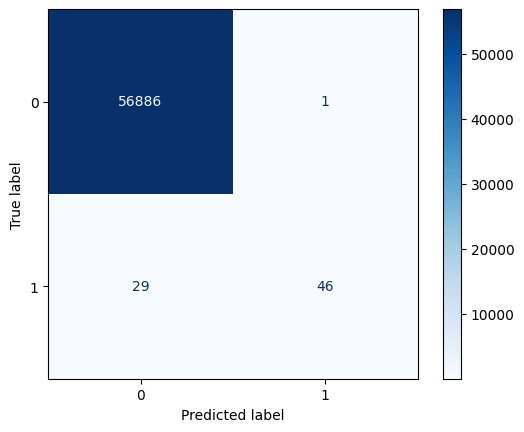

In [8]:
print(classification_report(y_test, baseline_y_pred))
cm_baseline = confusion_matrix(y_test, baseline_y_pred)
disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=baseline_model.classes_)
disp_baseline.plot(cmap=plt.cm.Blues)
plt.show()

In [9]:
class Value(ABC):
    def evaluate(self):
        pass

class Scalar(ABC):
    pass

class Vectorial(ABC):
    pass

In [10]:
@dataclass
class PastValues(Vectorial):
    index: Annotated[int, IntRange(0, n_features-1)]
    lookback: Annotated[int, IntRange(5, 15)]

    def evaluate(self, X_np, i):
        start_index = max(0, i-self.lookback+1)
        values = X_np[start_index: i+1, self.index]
        if len(values) < self.lookback: #if there are not enough past values
            padding = np.zeros(self.lookback - len(values))
            values = np.concatenate((padding, values))
        return values
    def __str__(self):
        return f"past_values({feature_names[self.index]}, {self.lookback})"

In [11]:
@dataclass
class Mean(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.mean(v)
    def __str__(self):
        return f"mean({self.arr})"
    
@dataclass
class Max(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.max(v)
    def __str__(self):
        return f"max({self.arr})"
    
@dataclass
class Min(Scalar):
    arr: Vectorial
    def evaluate(self, X_np, i):
        v = self.arr.evaluate(X_np,i)
        return np.min(v)
    def __str__(self):
        return f"min({self.arr})"


In [12]:
@dataclass #Scalar Features (1)
class ScalarVar(Scalar): 
    index: Annotated[int, IntRange(0,n_features-1)]

    def evaluate(self, X_np, i):
        return X_np[i, self.index]
    
    def __str__(self):
        return feature_names[self.index]

# @dataclass #Vectorial Features ([1,2,3,4])
# class VectorialVar(Vectorial):
#     index: Annotated[int, IntRange(1,2)]
    
#     def evaluate(self, X):
#         return X[self.index]

In [13]:
#scalar -> scalar
@dataclass 
class Add(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return self.left.evaluate(X_np,i) + self.right.evaluate(X_np,i)
    
    def __str__(self):
        return f"({self.left} + {self.right})"

@dataclass
class Subtract(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return (self.left.evaluate(X_np,i)) - (self.right.evaluate(X_np,i))
    
    def __str__(self):
        return f"({self.left} - {self.right})"
    
@dataclass
class Multiply(Scalar):
    right: Scalar
    left: Scalar

    def evaluate(self, X_np, i):
        return self.left.evaluate(X_np,i) * self.right.evaluate(X_np,i)
    
    def __str__(self):
        return f"({self.left} * {self.right})"

In [14]:
grammar = extract_grammar([PastValues, Mean, Max, Min, ScalarVar, Add, Subtract, Multiply], Scalar)
# grammar = extract_grammar([Add, Subtract, Multiply, ScalarVar], Scalar)
print(f"Grammar: {repr(grammar)}")

Grammar: Grammar<Starting=Scalar,Productions={
Scalar -> Mean(arr: Vectorial)|
	Max(arr: Vectorial)|
	Min(arr: Vectorial)|
	ScalarVar(index: Annotated[int])|
	Add(right: Scalar, left: Scalar)|
	Subtract(right: Scalar, left: Scalar)|
	Multiply(right: Scalar, left: Scalar)

Vectorial -> PastValues(index: Annotated[int], lookback: Annotated[int])
}


In [ ]:
X_train_np = X_train.to_numpy()
X_val_np = X_test.to_numpy()

def fitness_function(individual: Value): #individual -> expression
    # start = time.perf_counter()

    train_feature = [individual.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    val_feature = [individual.evaluate(X_val_np, i) for i in range(len(X_val_np))]

    X_train_new = np.array(train_feature).reshape(-1,1)
    X_val_new = np.array(val_feature).reshape(-1,1)

    features, num_operations = analyse_complexity(individual)

    num_features = len(features)

    if num_operations == 0:
        num_operations = 1

    model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train_new, y_train)
    y_pred_val = model.predict(X_val_new)

    # elapsed = time.perf_counter() - start

    # return [f1_score(y_test, y_pred_val), elapsed, num_features, num_operations]
    # return [f1_score(y_test, y_pred_val), num_features, num_operations]
    # return [f1_score(y_test, y_pred_val), num_operations]
    return [f1_score(y_test, y_pred_val), num_operations]
    # return [f1_score(y_test, y_pred_val)]

def analyse_complexity(individual: Value):
    if isinstance(individual, ScalarVar):
        return {individual.index}, 0 #unique feature
    if isinstance(individual, PastValues): 
        return {individual.index}, 0
    
    total_features = set()
    total_operations = 1
    if hasattr(individual, 'left') and hasattr(individual, 'right'):
        left_features, left_operations = analyse_complexity(individual.left)
        right_features, right_operations = analyse_complexity(individual.right)
        total_features.update(left_features)
        total_features.update(right_features)
        total_operations += left_operations + right_operations
    elif hasattr(individual, 'arr'):
        # if isinstance(individual, Mean) and isinstance(individual.arr, PastValues):
            # total_operations += individual.arr.lookback
        arr_features, arr_operations = analyse_complexity(individual.arr)
        total_features.update(arr_features)
        total_operations += arr_operations
    return total_features, total_operations


In [ ]:
def lexicase_step():
    return ParallelStep(
        [
            ElitismStep(),
            NoveltyStep(),
            SequenceStep(
                LexicaseSelection(True),
                # TournamentSelection(5),
                GenericCrossoverStep(0.9),
                GenericMutationStep(0.1),
            ),
        ],
        weights=[.1,.1,.8]
    )
prob = MultiObjectiveProblem(
    fitness_function=fitness_function,
    # minimize=[False, True, True, True],
    # minimize=[False, True, True],
    minimize=[False, True],
    # minimize=[False],
)
r = NativeRandomSource(123)
alg = GeneticProgramming(
    problem=prob,
    budget=TimeBudget(400),
    population_size=50,
    representation=TreeBasedRepresentation(grammar, MaxDepthDecider(r, grammar, 10)),
    # representation=StructuredGrammaticalEvolutionRepresentation(grammar, FullDecider(r, grammar, 4)),
    random=r,
    # population_initializer=FullInitializer(max_depth=3),
    step=lexicase_step(),
    tracker=ProgressTracker(
        prob,
        recorders=[CSVSearchRecorder(
            csv_path='output.csv', 
            problem=prob, 
            fields={
                    # "Eval Time": lambda t,i,p: i.get_fitness(p).fitness_components[1],
                    "F1 Score": lambda t,i,p: i.get_fitness(p).fitness_components[0],
                    "Expression": lambda t, i, p: i.get_phenotype(),
                    # 'Num Features': lambda t,i,p: i.get_fitness(p).fitness_components[2],
                    'Num Operations': lambda t,i,p: i.get_fitness(p).fitness_components[1]
                    },
            only_record_best_individuals=False)]
    )
    
)

solutions = alg.search()

In [126]:
sorted_solutions = sorted(solutions, key=lambda ind: ind.get_fitness(prob).fitness_components[0], reverse=True)

unique_solutions = []
seen_expressions = set()
for s in sorted_solutions:
    expr = str(s.get_phenotype())
    if expr not in seen_expressions:
        unique_solutions.append(s)
        seen_expressions.add(expr)

In [127]:
for i,s in enumerate(unique_solutions[:10]):
    print(f"Solution {i}:")
    print(f"Expression: {s.get_phenotype()}")
    print(f"Fitness: {s.get_fitness(prob).fitness_components}\n")

Solution 0:
Expression: V12
Fitness: [1, 0.4393939393939394]



In [128]:
top_n_solutions = unique_solutions[:10]

In [129]:
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()
for i, target in enumerate(top_n_solutions):
    expression = target.get_phenotype()
    train_feature_values = [expression.evaluate(X_train_np, i) for i in range(len(X_train_np))]
    test_features_values = [expression.evaluate(X_test_np, i) for i in range(len(X_test_np))]

    
    X_train_fe[f'new_feature_{i}'] = train_feature_values
    X_test_fe[f'new_feature_{i}'] = test_features_values

In [130]:
X_train_fe.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,new_feature_0
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.233543,-0.617801
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.357878,1.065235
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.155473,0.066084
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.128406,0.178228
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.086982,0.538196


In [131]:
# model_with_new_feature = DecisionTreeClassifier(random_state=42)
model_with_new_feature = RandomForestClassifier(random_state=42, class_weight='balanced')
model_with_new_feature.fit(X_train_fe, y_train)

y_pred_with_new_feature = model_with_new_feature.predict(X_test_fe)
f1_with_new_feature = f1_score(y_test, y_pred_with_new_feature)
print(f1_with_new_feature)
print(model_with_new_feature.feature_importances_)

0.7540983606557377
[0.00486769 0.00627915 0.01914247 0.07251922 0.05201591 0.00676754
 0.00603592 0.02752175 0.00887588 0.01452636 0.14145151 0.05410304
 0.09207323 0.00885442 0.18191695 0.00662764 0.02918617 0.05376395
 0.01406778 0.01160927 0.00934995 0.01497821 0.00640601 0.00561698
 0.00459398 0.00526088 0.00434141 0.01228508 0.00533668 0.01153378
 0.1080912 ]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.98      0.61      0.75        75

    accuracy                           1.00     56962
   macro avg       0.99      0.81      0.88     56962
weighted avg       1.00      1.00      1.00     56962



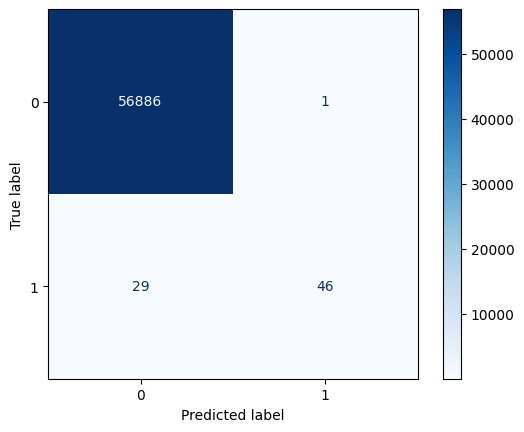

In [132]:
print(classification_report(y_test, y_pred_with_new_feature))
cm = confusion_matrix(y_test, y_pred_with_new_feature)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_with_new_feature.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [133]:
temp_df = X_train_fe.copy()
temp_df['Class'] = y_train

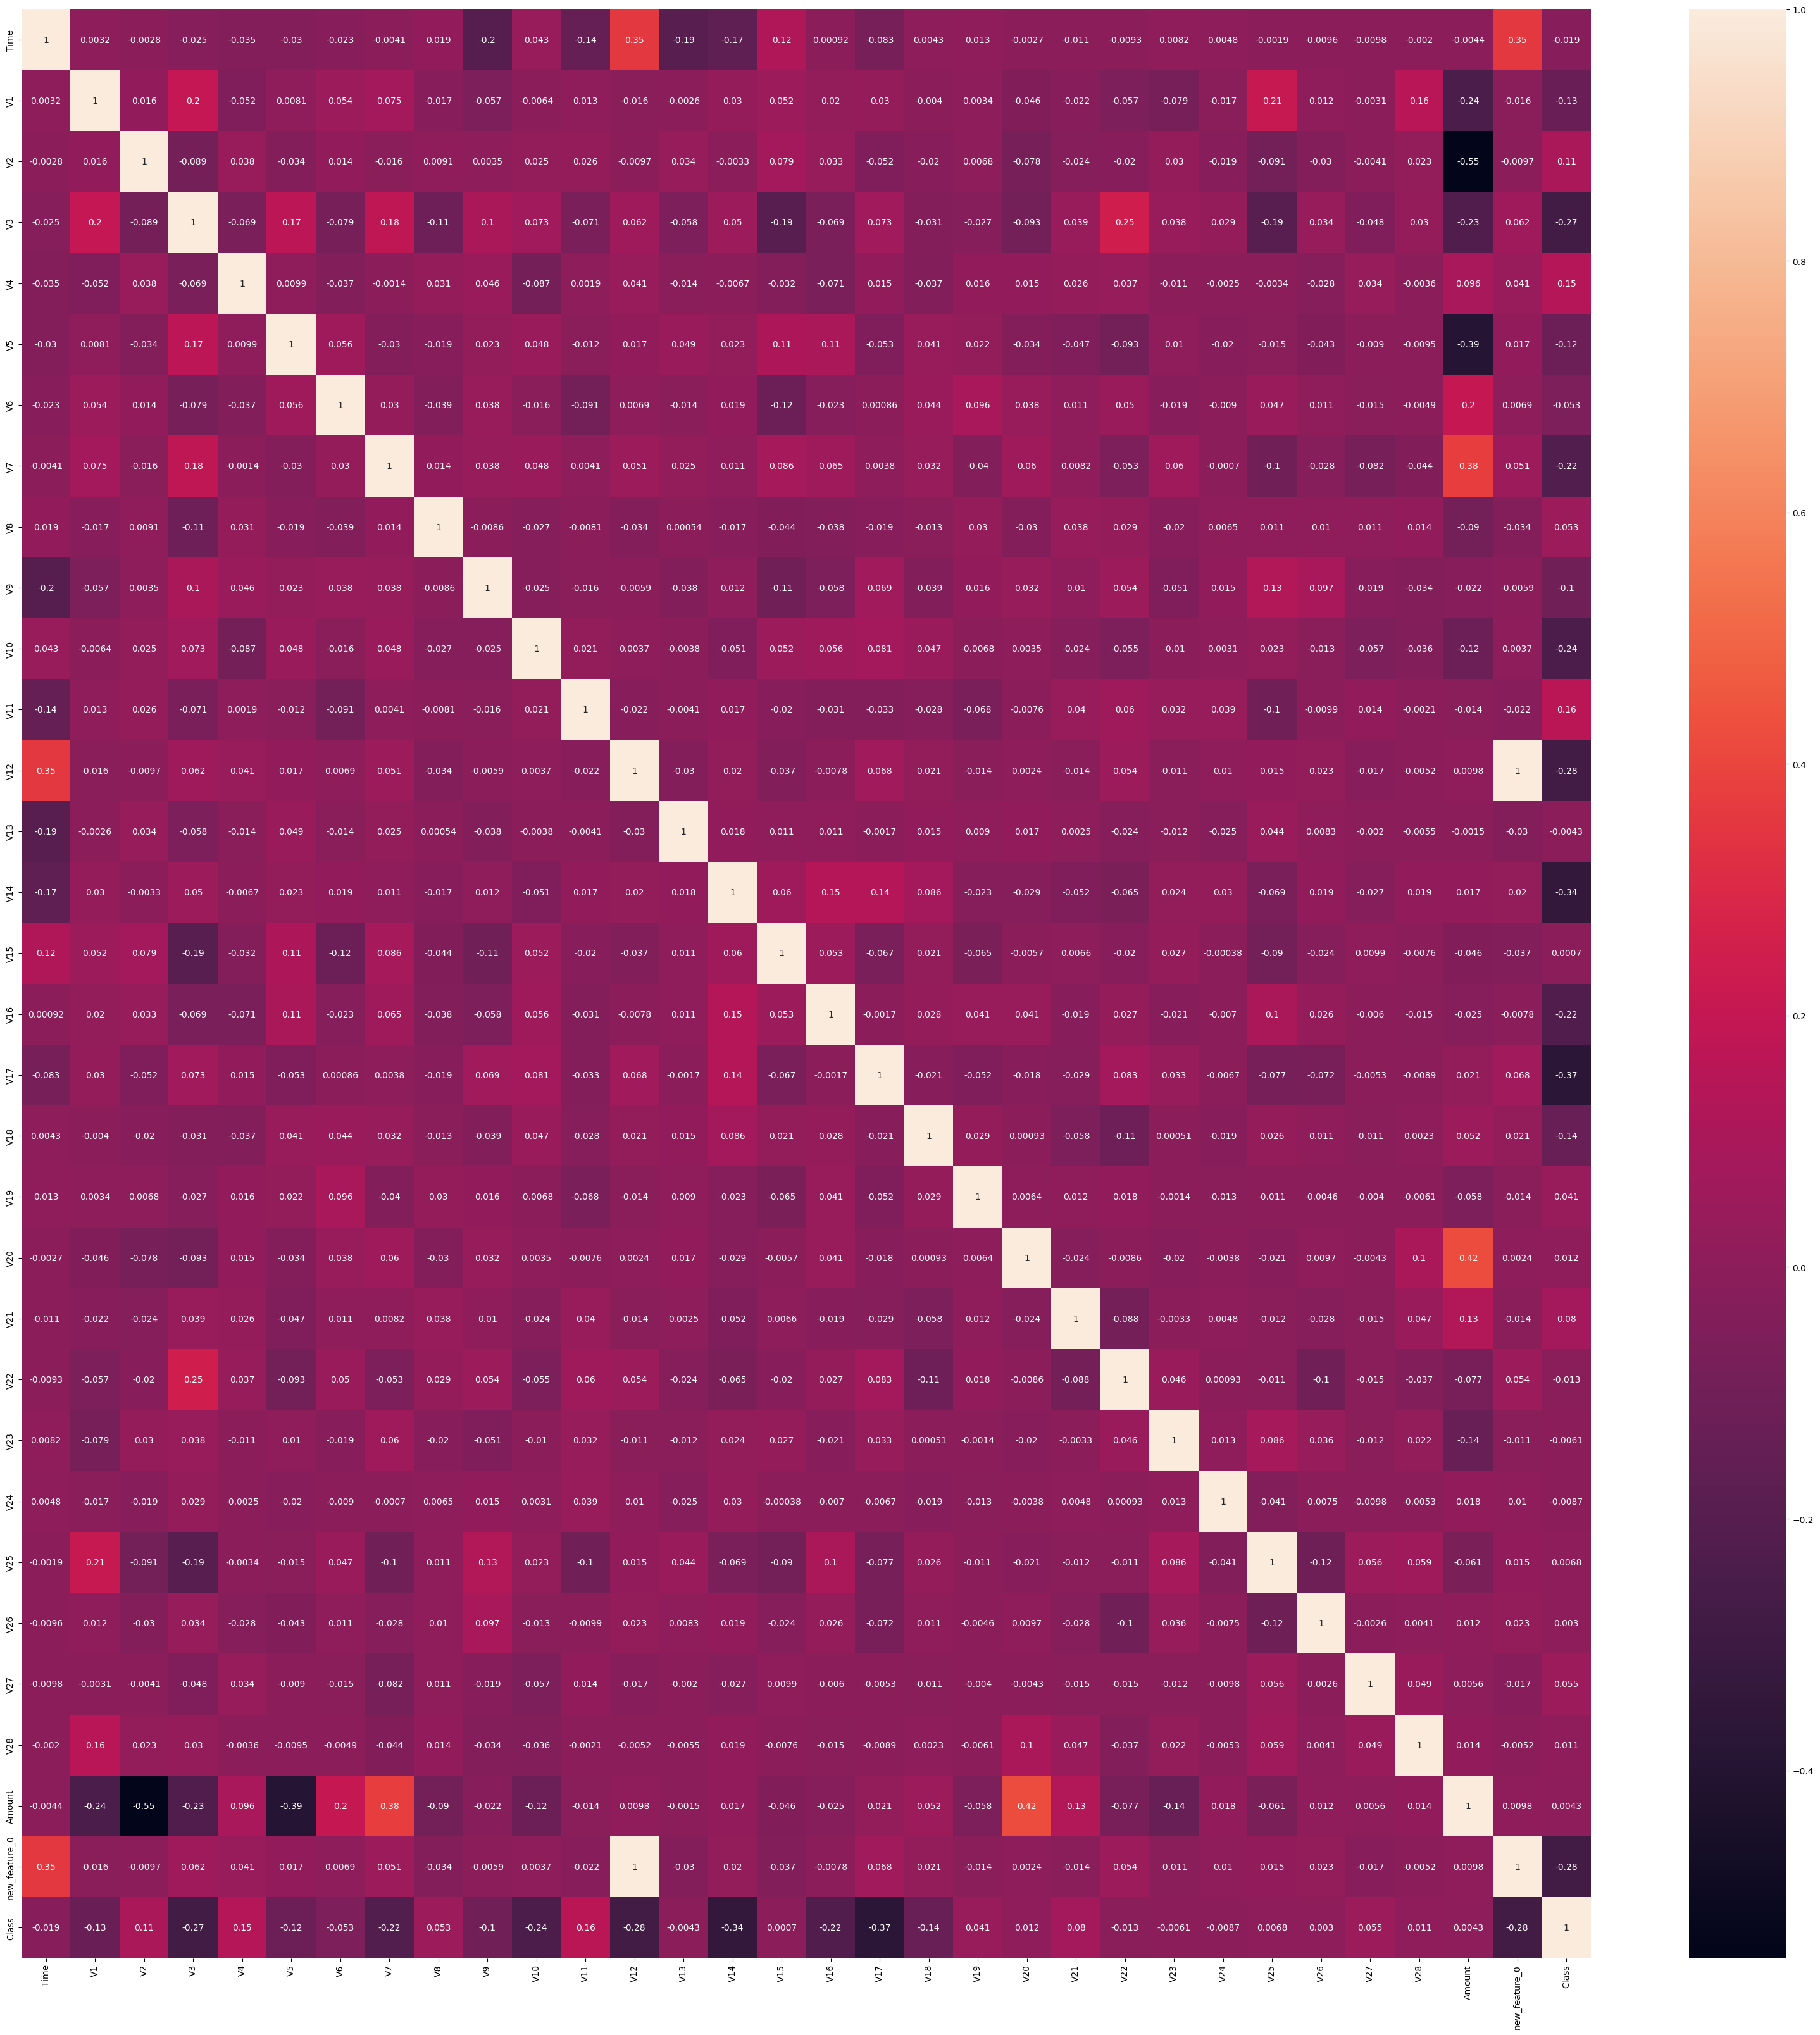

In [134]:
correlation_matrix = temp_df.corr()
plt.figure(figsize=(40,40))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [135]:
# test = Max(arr=PastValues(index=feature_names.index('worst fractal dimension'), lookback=4))

# generated_value = [test.evaluate(X_test, i) for i in range(len(X_test))]

# test_df = X_test.copy()
# test_df['generated'] = generated_value
# test_df['target_x'] = y_test
# test_df.head(10)